In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist #Dígitos manuscritos (70000 muestras)

In [ ]:
(x_train, y_train),(x_test, y_test)= fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Forma de la imagen:", x_test[0].shape)
print('Forma de x_train', x_train.shape)
print('Forma de x_train', x_test.shape)
print('Total del muestras', (len(y_train)+len(y_test)))



Forma de la imagen: (28, 28)
Forma de x_train (60000, 28, 28)
Forma de x_train (10000, 28, 28)
Total del muestras 70000


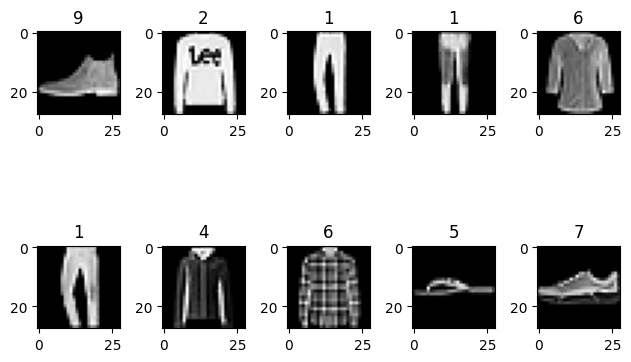

In [ ]:
for s in range(10):
  plt.subplot(2,5, s+1)
  plt.imshow(x_test[s], cmap = "gray")
  plt.title(y_test[s])
plt.tight_layout()


In [ ]:
x_train = x_train/255.0
x_test = x_test/255.0
"print(x_test[0])"

'print(x_test[0])'

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28)), #Convertimos la imagen 2d a un vector plano de numeros(las capas densas solo admiten imagenes planas)
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8233 - loss: 0.5011
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8647 - loss: 0.3748
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8785 - loss: 0.3361
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8852 - loss: 0.3129
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8909 - loss: 0.2960
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8968 - loss: 0.2802
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9005 - loss: 0.2689
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9049 - loss: 0.2558
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9076 - loss: 0.2479
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9119 - loss: 0.2380
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9139 - loss: 0.2309
Epoch 12/15
1875/1875 ━━━━━━━

In [ ]:
class_names = [
    'T-shirt/top (Camiseta)', 'Trouser (Pantalón)', 'Pullover (Pulóver)',
    'Dress (Vestido)', 'Coat (Abrigo)', 'Sandal (Sandalia)',
    'Shirt (Camisa)', 'Sneaker (Zapatilla)', 'Bag (Bolso)', 'Ankle boot (Botín)'
]
print(class_names[0])

T-shirt/top (Camiseta)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Salida de probabilidades de nuestro softmax [[9.8099110e-07 6.8929563e-13 2.0705907e-11 2.4783659e-15 5.5588478e-10
  9.9999905e-01 8.5201360e-11 8.4560829e-09 6.3110978e-10 3.4734577e-15]]
Afinando la salida [5] Sandal (Sandalia)
Etiqueta real 5 Sandal (Sandalia)


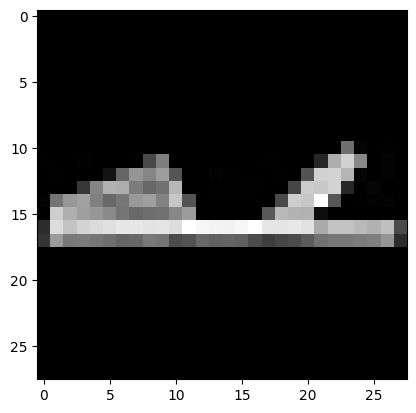

In [ ]:
muestra= x_test[111].reshape(1,28,28)
predict= model.predict(muestra)

print('Salida de probabilidades de nuestro softmax', predict)
print('Afinando la salida', predict.argmax(1), class_names[predict.argmax(1)[0]])
print('Etiqueta real', y_test[111], class_names[y_test[111]])
plt.imshow(muestra.reshape(28,28), cmap = 'gray')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
--- Prenda 111 ---
Afinando la salida: 5 Sandal (Sandalia)
Etiqueta real: 5 Sandal (Sandalia)
------------------------------
--- Prenda 112 ---
Afinando la salida: 7 Sneaker (Zapatilla)
Etiqueta real: 7 Sneaker (Zapatilla)
------------------------------
--- Prenda 113 ---
Afinando la salida: 0 T-shirt/top (Camiseta)
Etiqueta real: 0 T-shirt/top (Camiseta)
------------------------------
--- Prenda 114 ---
Afinando la salida: 5 Sandal (Sandalia)
Etiqueta real: 5 Sandal (Sandalia)
------------------------------
--- Prenda 115 ---
Afinando la salida: 2 Pullover (Pulóver)
Etiqueta real: 2 Pullover (Pulóver)
------------------------------
--- Prenda 116 ---
Afinando la salida: 8 Bag (Bolso)
Etiqueta real: 8 Bag (Bolso)
------------------------------
--- Prenda 117 ---
Afinando la salida: 6 Shirt (Camisa)
Etiqueta real: 6 Shirt (Camisa)
------------------------------
--- Prenda 118 ---
Afinando la salida: 7 Sneaker (Zapatilla)
Etiqueta real: 7 Sneaker (Za

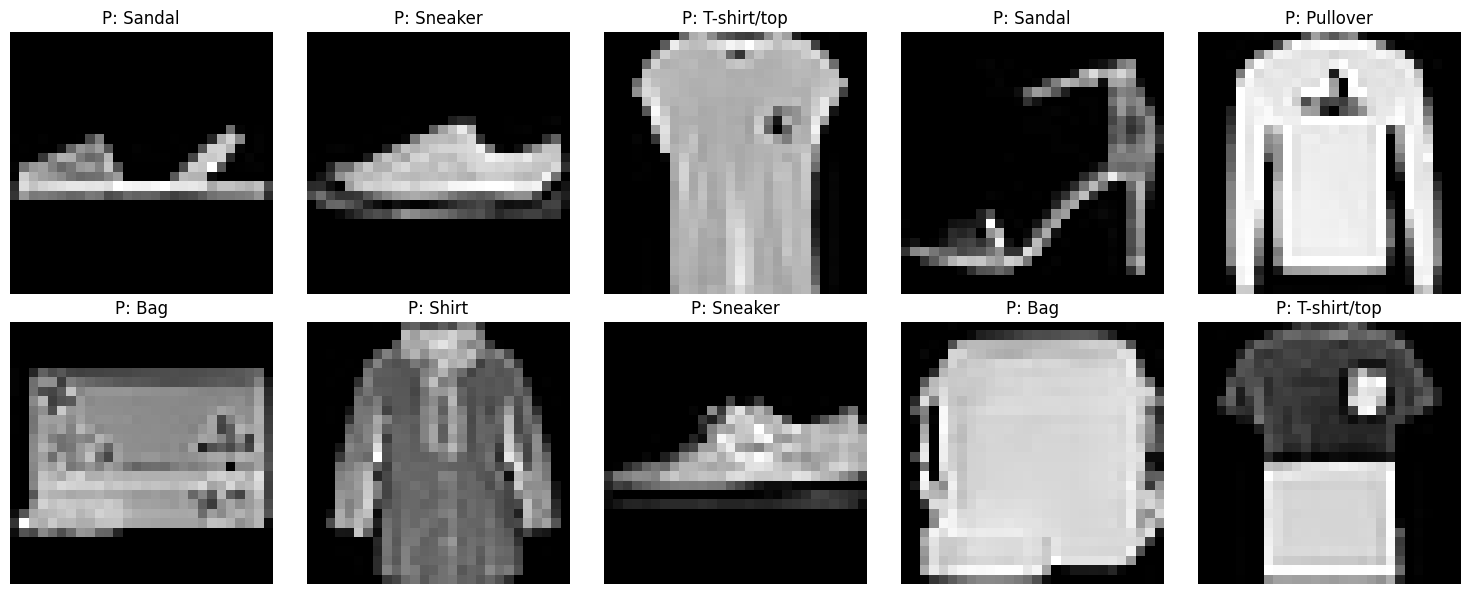

In [ ]:
muestras = x_test[111:121]
predicts = model.predict(muestras)

indices_predicciones = predicts.argmax(1)


for i in range(10):
    idx_real = y_test[111 + i]        # Índice real de cada prenda
    idx_pred = indices_predicciones[i]   # Índice predicho por el modelo

    print(f"--- Prenda {111 + i} ---")
    print('Afinando la salida:', idx_pred, class_names[idx_pred])
    print('Etiqueta real:', idx_real, class_names[idx_real])
    print("-" * 30)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(muestras[i], cmap='gray')
    plt.title(f"P: {class_names[indices_predicciones[i]].split(' ')[0]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"El modelo tiene una precisión global del: {test_acc * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8814 - loss: 0.3560
El modelo tiene una precisión global del: 88.14%
